In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

Dataset Loading

In [ ]:
#Q1. Load the Amazon_Sales.xlsx dataset into a Pandas DataFrame and display the first five records.

data=pd.read_excel("amazon-dataset.xlsx")
df=pd.DataFrame(data)
print(df.head(5))

      OrderID  OrderDate  CustomerID   CustomerName ProductID  \
0  ORD0000001 2023-01-31  CUST001504  Vihaan Sharma    P00014   
1  ORD0000002 2023-12-30  CUST000178    Pooja Kumar    P00040   
2  ORD0000003 2022-05-10  CUST047516    Sneha Singh    P00044   
3  ORD0000004 2023-07-18  CUST030059   Vihaan Reddy    P00041   
4  ORD0000005 2023-02-04  CUST048677  Aditya Kapoor    P00029   

           ProductName        Category       Brand  Quantity  UnitPrice  \
0           Drone Mini           Books   BrightLux         3     106.59   
1           Microphone  Home & Kitchen  UrbanStyle         1     251.37   
2  Power Bank 20000mAh        Clothing  UrbanStyle         3      35.03   
3       Webcam Full HD  Home & Kitchen      Zenith         5      33.58   
4              T-Shirt        Clothing    KiddoFun         2     515.64   

   Discount    Tax  ShippingCost  TotalAmount     PaymentMethod OrderStatus  \
0      0.00   0.00          0.09       319.86        Debit Card   Delivered   


Dataset Overview

In [ ]:
#Q2. Display:

# Number of rows and columns

print(df.shape)



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   OrderID        100000 non-null  object        
 1   OrderDate      100000 non-null  datetime64[ns]
 2   CustomerID     100000 non-null  object        
 3   CustomerName   100000 non-null  object        
 4   ProductID      100000 non-null  object        
 5   ProductName    100000 non-null  object        
 6   Category       100000 non-null  object        
 7   Brand          100000 non-null  object        
 8   Quantity       100000 non-null  int64         
 9   UnitPrice      100000 non-null  float64       
 10  Discount       100000 non-null  float64       
 11  Tax            100000 non-null  float64       
 12  ShippingCost   100000 non-null  float64       
 13  TotalAmount    100000 non-null  float64       
 14  PaymentMethod  100000 non-null  object        
 15  O

In [ ]:
#Column names

print("Column names : ",df.columns)

Column names :  Index(['OrderID', 'OrderDate', 'CustomerID', 'CustomerName', 'ProductID',
       'ProductName', 'Category', 'Brand', 'Quantity', 'UnitPrice', 'Discount',
       'Tax', 'ShippingCost', 'TotalAmount', 'PaymentMethod', 'OrderStatus',
       'City', 'State', 'Country', 'SellerID'],
      dtype='object')


In [ ]:
# Data types
print(df.info())

In [ ]:
# Statistical summary of numerical columns

print(df.describe())

                        OrderDate       Quantity      UnitPrice  \
count                      100000  100000.000000  100000.000000   
mean   2022-06-30 23:55:49.440000       3.001400     302.905748   
min           2020-01-01 00:00:00       1.000000       5.000000   
25%           2021-04-01 00:00:00       2.000000     154.190000   
50%           2022-07-01 00:00:00       3.000000     303.070000   
75%           2023-09-29 00:00:00       4.000000     451.500000   
max           2024-12-29 00:00:00       5.000000     599.990000   
std                           NaN       1.413548     171.840797   

            Discount            Tax   ShippingCost    TotalAmount  
count  100000.000000  100000.000000  100000.000000  100000.000000  
mean        0.074226      68.468902       7.406660     918.256479  
min         0.000000       0.000000       0.000000       4.270000  
25%         0.000000      15.920000       3.680000     340.890000  
50%         0.050000      45.250000       7.300000     7

In [ ]:
# KPI Analysis

# Q3. Calculate the following KPIs:

# Total Sales
print(df["TotalAmount"].sum())


91825647.92


In [ ]:
#Total Orders

print(df["OrderID"].count())

100000


In [ ]:
#Average Sales

print(df["TotalAmount"].mean())

918.2564792000001


In [ ]:
#Maximum Quantity

print(df["Quantity"].max())

5


In [ ]:
#Maximum Sales

print(df["TotalAmount"].max())

3534.98


In [ ]:
#Minimum Sales

print(df['TotalAmount'].min())

4.27


In [ ]:
# Sales Analysis

# Q4. Find the total sales generated by each State and display the results in descending order

grouped_by=df.groupby("State")["TotalAmount"].sum()
print(grouped_by.sort_values(ascending=False))

State
TX    22862540.54
CA    18231196.79
NC     4747701.73
WA     4660962.17
PA     4650673.88
CO     4638498.97
IL     4632847.44
OH     4615442.32
IN     4609048.43
FL     4597177.27
NY     4554358.08
DC     4520876.11
AZ     4504324.19
Name: TotalAmount, dtype: float64


In [ ]:
#Q5. Find the total sales generated by each Category.
grouped_by=df.groupby("Category")["TotalAmount"].sum()
print(grouped_by)

Category
Books                15261837.01
Clothing             15253397.50
Electronics          15584217.18
Home & Kitchen       15163939.36
Sports & Outdoors    15345571.88
Toys & Games         15216684.99
Name: TotalAmount, dtype: float64


In [ ]:
#Customer & Product Analysis

# Q7. Display the Top 5 Customers based on total sales.

df.groupby("CustomerID")["TotalAmount"].sum().sort_values(ascending=False).head()

,TotalAmount
CustomerID,
CUST023748,15215.79
CUST009614,12160.96
CUST034178,11418.88
CUST001153,11282.96
CUST004883,11214.44


In [ ]:
#Q8. Find the total quantity sold for each product.

df.groupby("ProductName")["Quantity"].sum()

,Quantity
ProductName,
4K Monitor,6111
Action Camera,6104
Air Fryer,5956
Backpack,5848
Bluetooth Speaker,5782
Board Game,6200
Car Charger,5754
Children's Book,5619
Cookware Set,6130


In [ ]:
# Payment Analysis

# Q9. Find the number of orders placed using each Payment Mode.

df.groupby("PaymentMethod")["OrderID"].count()

,OrderID
PaymentMethod,
Amazon Pay,15017
Cash on Delivery,4928
Credit Card,35038
Debit Card,20024
Net Banking,9927
UPI,15066


In [ ]:
# Time-based Analysis

# Q10. Calculate the monthly sales trend using the Order Date column.

df["Month"] = df["OrderDate"].dt.strftime("%B")
df.groupby("Month")["TotalAmount"].sum()


,TotalAmount
Month,
April,7646203.22
August,7890598.37
December,7740979.01
February,6931724.49
January,7883801.27
July,7737925.51
June,7654636.75
March,7766527.73
May,7864283.27


In [ ]:
#Q11. Find the sales generated by each State for every Category.

df.groupby(["State","Category"])["TotalAmount"].sum()


State  Category         
AZ     Books                793211.33
       Clothing             691249.82
       Electronics          747955.37
       Home & Kitchen       737616.34
       Sports & Outdoors    694318.06
                              ...    
WA     Clothing             747668.70
       Electronics          879580.90
       Home & Kitchen       809448.28
       Sports & Outdoors    807282.60
       Toys & Games         711514.12
Name: TotalAmount, Length: 78, dtype: float64

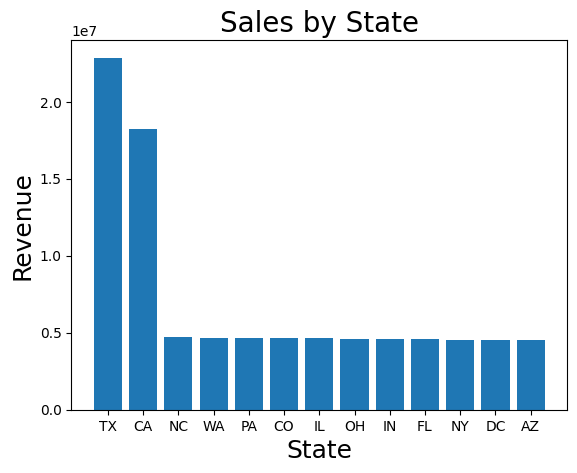

In [ ]:
#Visualization

# Q12. Create a Bar Chart showing Sales by State.

grouped_by=df.groupby("State")["TotalAmount"].sum().sort_values(ascending=False)

plt.bar(grouped_by.index,grouped_by.values)
plt.xlabel("State",fontsize=18)
plt.ylabel("Revenue",fontsize=18)
plt.title("Sales by State",fontsize=20)
plt.show()

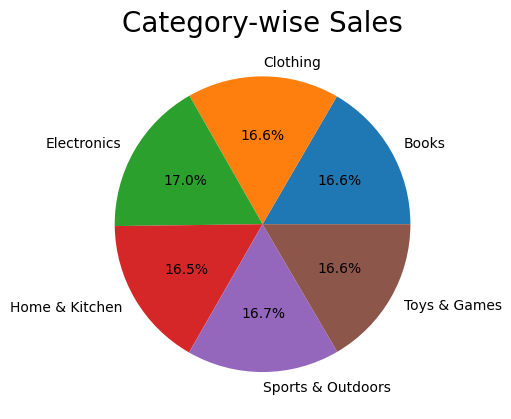

In [ ]:
#Q13. Create a Pie Chart showing Category-wise Sales.

grouped_by=df.groupby("Category")["TotalAmount"].sum()

plt.pie(grouped_by.values,labels=grouped_by.index,autopct='%1.1f%%')
plt.title("Category-wise Sales",fontsize=20)
plt.show()

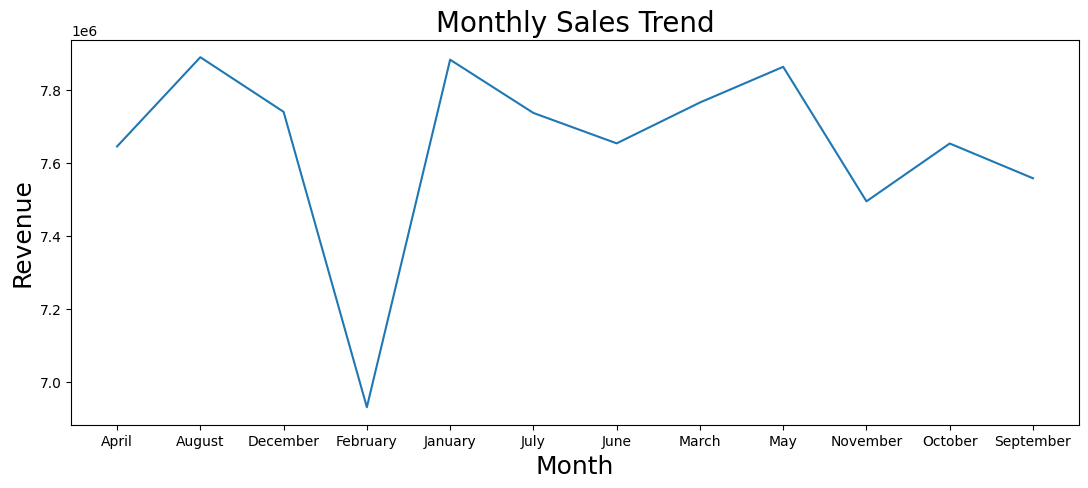

In [ ]:
# Q14. Create a Line Chart showing Monthly Sales Trend.

grouped_by=df.groupby("Month")["TotalAmount"].sum()

plt.figure(figsize=(13, 5))

plt.plot(grouped_by.index,grouped_by.values,)

plt.xlabel("Month",fontsize=18)
plt.ylabel("Revenue",fontsize=18)
plt.title("Monthly Sales Trend",fontsize=20)
plt.show()

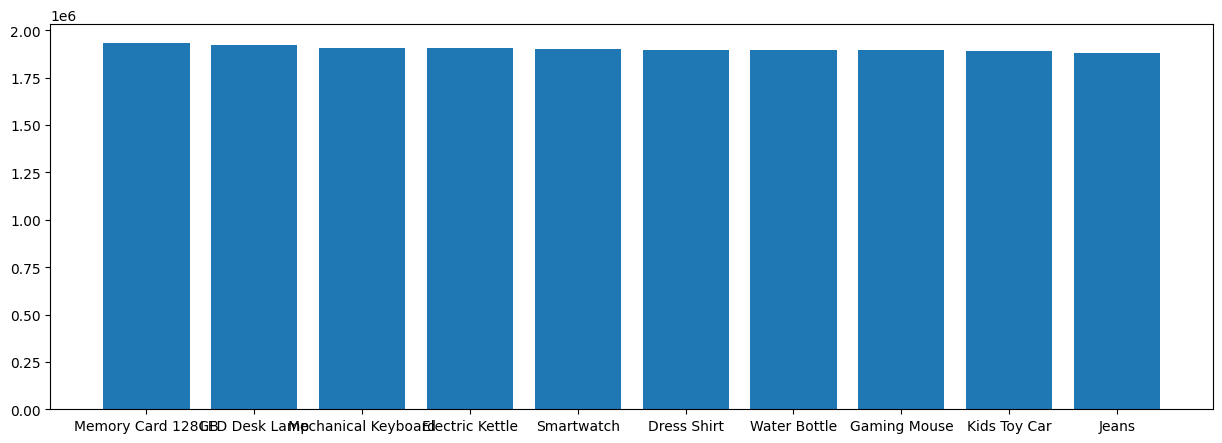

In [ ]:
#Q15. Create a Horizontal Bar Chart showing the Top 10 Products by Sales.

grouped_by=df.groupby("ProductName")["TotalAmount"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(15, 5))
plt.bar(grouped_by.index,grouped_by.values)
plt.show()
